In [1]:
from os.path import dirname, abspath,join
from os import makedirs
import sys
import numpy as np
import pandas as pd
import json
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

root_path = dirname(abspath("./"))
import sys
sys.path.append(root_path)
from causaliT.evaluation.predict import *
from causaliT.training.forecasters.transformer_forecaster import TransformerForecaster

# plotting standard settings
plt.rcParams['figure.dpi'] = 100 #360 # standard is 360 but for set to 100 for practical visualization on the notebook
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['lines.linewidth'] = 1.5

datadir_path = r"../data/"

In [16]:
config_path = r"../experiments/stage_SoftMax_scm6/config_stage_causaliT_v1.yaml"
config = OmegaConf.load(config_path)

checkpoint_path = r"../experiments/stage_SoftMax_scm6/k_0/checkpoints/epoch=1-train_loss=0.01.ckpt"

results = predict_test_from_ckpt(
    config, 
    datadir_path, 
    checkpoint_path,
    dataset_label="test")

Seed set to 42


Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Test dataset selected.
Predicting...


  4%|▍         | 7/157 [00:11<04:05,  1.64s/it]


RuntimeError: DataLoader worker (pid(s) 26068, 40416, 40560) exited unexpectedly

(array([[  1.,   0.,   0.,   1.,   1.,   1.,   0.,   1.,   0.,   1.,   5.,
           6.,   8.,   5.,   6.,   7.,  15.,  20.,  13.,  27.,  35.,  32.,
          34.,  49.,  40.,  61.,  67.,  83.,  86.,  97.,  79., 120., 104.,
         118., 133., 145., 160., 187., 197., 186., 235., 185., 212., 217.,
         220., 250., 242., 257., 270., 252., 255., 297., 249., 270., 263.,
         284., 262., 243., 256., 240., 244., 216., 212., 222., 182., 179.,
         173., 141., 147., 135., 123., 115., 100., 103.,  76.,  57.,  74.,
          61.,  58.,  42.,  38.,  46.,  32.,  19.,  25.,  25.,  11.,   8.,
          18.,   8.,   6.,   5.,   0.,   2.,   2.,   0.,   0.,   2.,   0.,
           3.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
           0.,   1.,   1.,   1.,   2.,   1.,   8.,   2.,   9.,  13.,   6.,
           8.,  17.,  21.,  27.,  32.,  38.,  56.,  74.,  59.,  90.,  96.,
         101., 126., 144., 146., 174., 206., 205., 221., 247., 242., 269.,
         

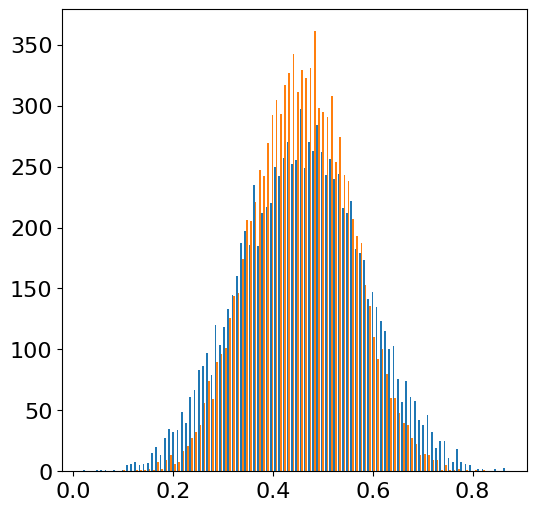

In [11]:
plt.hist(results.outputs, bins=100)

In [ ]:

# Intervene on S1 (variable_id=1), setting all S1 values to 0.0
intervention_fn_S1 = create_intervention_fn(interventions={1: 0.0})

# Intervene on S2 (variable_id=2), setting all S1 values to 0.0
intervention_fn_S2 = create_intervention_fn(interventions={2: 0.0})

# Intervene on S3 (variable_id=2), setting all S1 values to 0.0
intervention_fn_S2 = create_intervention_fn(interventions={3: 0.0})

# Run prediction with intervention
results_do_S1 = predict_test_from_ckpt(
    config, datadir_path, checkpoint_path,
    input_conditioning_fn=intervention_fn_S1
)

Seed set to 42


Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Loading single data file (S, X, Y format).
Data shapes - S: (50000, 3, 2), X: (50000, 2, 2), Y: (50000, 2, 2)
Test dataset selected.
Predicting...


100%|██████████| 157/157 [00:06<00:00, 22.78it/s]


(array([[  2.,   2.,   3.,   2.,   4.,   4.,   6.,   5.,   4.,  13.,  12.,
          18.,  20.,  27.,  33.,  37.,  53.,  56.,  64.,  72.,  73.,  92.,
         100., 124., 137., 172., 170., 155., 198., 206., 231., 234., 238.,
         249., 279., 273., 253., 268., 272., 299., 269., 275., 273., 306.,
         265., 265., 272., 251., 251., 241., 211., 216., 202., 206., 188.,
         158., 172., 148., 137., 123., 146., 112., 105.,  90.,  80.,  85.,
          85.,  53.,  51.,  48.,  36.,  37.,  34.,  25.,  16.,  23.,  13.,
           9.,   9.,  17.,   8.,   8.,   2.,   4.,   6.,   3.,   1.,   1.,
           0.,   1.,   2.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           1.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   1.,   3.,   2.,   2.,   5.,   6.,   5.,   7.,  10.,
          13.,  13.,  19.,  41.,  39.,  42.,  65.,  87.,  76., 111., 132.,
         141., 162., 207., 225., 233., 270., 273., 318., 344., 341., 320.,
         

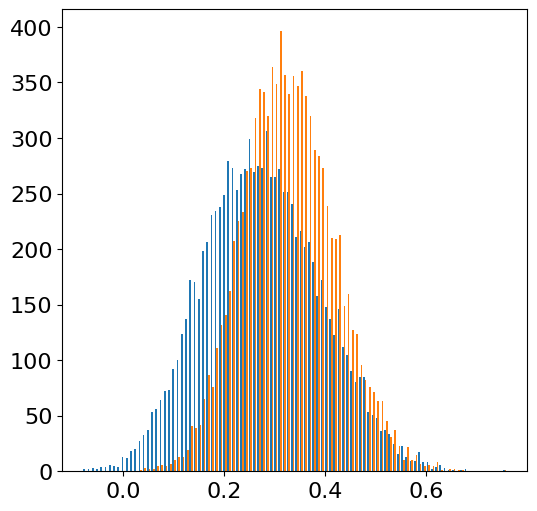

In [ ]:
plt.hist(results_do_S1.outputs, bins=100)